## Load data

Loading data from the Benign/Dictionary Brute Force/DNS_Spoofing dataset.

In [2]:
import pandas as pd

# Read Benign Traffic
benign_data = pd.read_csv("./BenignTraffic.pcap.csv")
benign_data.head()
# Read Dictionary Brute Force
dict_brute_force_data = pd.read_csv("./DictionaryBruteForce.pcap.csv")
dict_brute_force_data.head()
# Reda DNS_Spoofing
dns_spoofing_data = pd.read_csv("./DNS_Spoofing.pcap.csv")
dns_spoofing_data.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
0,10.4,17,63.6,6427.067116,0.0,0.0,0.0,0.1,0.1,0.0,...,1.0,6391,140,1074,639.1,296.700541,639.1,0.000156,10,88031.211111
1,8.0,17,64.0,2434.868222,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6989,46,1074,698.9,343.381696,698.9,0.000655,10,117910.988889
2,9.2,17,59.8,1138.951828,0.0,0.0,0.0,0.1,0.1,0.0,...,1.0,4387,46,1074,438.7,483.072585,438.7,0.000955,10,233359.122222
3,8.0,17,50.0,4520.698426,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,7859,362,1074,785.9,259.964292,785.9,0.000221,10,67581.433333
4,8.0,17,51.4,1231.988251,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6164,356,796,616.4,217.480625,616.4,0.000851,10,47297.822222


Show statistics (such as mean, median, standard deviation etc.) of each column:

In [3]:
# Show statistics of the dataset
benign_data.describe()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
count,362361.000000,362361.000000,362361.000000,3.623610e+05,362361.000000,362361.000000,362361.000000,362361.000000,362361.000000,362361.000000,...,362361.000000,362361.000000,362361.000000,362361.000000,362361.000000,362342.000000,362361.000000,3.623610e+05,362361.000000,3.623420e+05
mean,26.701672,7.107147,108.504222,inf,0.022801,0.025565,0.001970,0.173028,0.769602,0.000337,...,0.975568,5475.835093,118.129713,1518.459876,547.956289,496.175465,547.956289,9.198666e-03,9.997696,6.483441e+05
std,6.983413,3.343224,48.370953,NaN,0.050855,0.052081,0.019888,0.156156,0.249253,0.006160,...,0.059382,6380.254167,271.149036,1955.290549,638.860704,634.157032,638.860704,9.299444e-03,0.118089,1.995883e+06
min,0.000000,0.000000,0.000000,7.697838e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,60.000000,60.000000,60.000000,60.000000,0.000000,60.000000,6.357829e-07,1.000000,0.000000e+00
25%,22.400000,6.000000,70.000000,8.522029e+01,0.000000,0.000000,0.000000,0.100000,0.600000,0.000000,...,1.000000,994.000000,60.000000,230.000000,99.400000,56.577282,99.400000,2.156687e-03,10.000000,3.200989e+03
50%,28.000000,6.000000,93.500000,1.610023e+02,0.000000,0.000000,0.000000,0.100000,0.888889,0.000000,...,1.000000,1728.000000,66.000000,573.000000,172.800000,154.712960,172.800000,7.059383e-03,10.000000,2.393610e+04
75%,32.000000,6.000000,131.400000,5.577235e+02,0.000000,0.000000,0.000000,0.300000,1.000000,0.000000,...,1.000000,9188.000000,66.000000,2858.000000,918.800000,762.428000,918.800000,1.279159e-02,10.000000,5.812965e+05
max,60.000000,17.000000,250.600000,inf,0.900000,1.000000,1.000000,1.000000,1.000000,0.400000,...,1.000000,94303.000000,13583.000000,37714.000000,13583.000000,11655.404669,13583.000000,1.388082e-01,10.000000,1.358485e+08


## Feature Extraction

Now that we have loaded the dataset, we can observe two kinds of columns: some columns, such as `src_bytes` and `dst_bytes`, are numerical; some others, like `label`, are categorical, in that there is only a limited number of possible values for them. For dimensionality reduction, we are not considering categorical columns as part of the features for now, as they require special processing. The following code extracts numerical features from the dataset:

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Extract numerical columns only and convert DataFrame to float type
benign_features = benign_data.copy()
dict_features = dict_brute_force_data.copy()
spoof_features = dns_spoofing_data.copy()

# Features obtained from `MinMaxScaler`
benign_minmax = pd.DataFrame()
dict_minmax = pd.DataFrame()
spoof_minmax = pd.DataFrame()

# Delete problematic feature
del benign_features["Rate"]
del dict_features["Rate"]
del spoof_features["Rate"]

for column in benign_features.columns:
    # 1) Convert column data to NumPy array and add an extra dimension
    arr = np.array(benign_features[column])[:, None]
    # 2) Re-scale data with `MinMaxScaler`
    arr_scaled = MinMaxScaler().fit_transform(arr).flatten()
    # 3) Update column with scaled result
    benign_minmax[column] = arr_scaled
    
for column in dict_features.columns:
    # 1) Convert column data to NumPy array and add an extra dimension
    arr = np.array(dict_features[column])[:, None]
    # 2) Re-scale data with `MinMaxScaler`
    arr_scaled = MinMaxScaler().fit_transform(arr).flatten()
    # 3) Update column with scaled result
    dict_minmax[column] = arr_scaled
    
for column in spoof_features.columns:
    # 1) Convert column data to NumPy array and add an extra dimension
    arr = np.array(spoof_features[column])[:, None]
    # 2) Re-scale data with `MinMaxScaler`
    arr_scaled = MinMaxScaler().fit_transform(arr).flatten()
    # 3) Update column with scaled result
    spoof_minmax[column] = arr_scaled

# Convert features to NumPy array
benign_minmax = benign_minmax.values
dict_minmax = dict_minmax.values
spoof_minmax = spoof_minmax.values

# Print the shape of the output to check
print(benign_minmax.shape)
print(dict_minmax.shape)
print(spoof_minmax.shape)


(362361, 38)
(13064, 38)
(178898, 38)


## Test/Train Set Split

After the sample is scaled properly, we do the test/train data split for training our autoencoder. To prevent problems, we need to group-based divide the dataset.

 Test/Train Set Split

After the sample is scaled properly, we do the test/train data split for training our autoencoder. To prevent problems, we need to group-based divide the dataset.

In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Features obtained from `StandardScaler`
kdd_feat_std = pd.DataFrame()

# Remove outliers for `StandardScaler`
remove_outliers = True
# Outlier threshold (standard deviation as unit)
outlier_threshold = 10
# Indices of records with outlier values
outlier_indices = set()

for col_name in kdd_features.columns:
    # Obtain column data as 2D NumPy array
    col_data = kdd_features[col_name].values.astype(float)[:, None]
    # Re-scale data with `StandardScaler`
    col_data = StandardScaler().fit_transform(col_data)

    if remove_outliers:
        # 1) Get indices of records with outlier column values
        outliers = np.where(np.abs(col_data.squeeze()) > outlier_threshold)[0]
        
        # 2) Merge these indices with `outlier_indices`
        outlier_indices.update(outliers)

    # Copy rescaled column
    kdd_feat_std[col_name] = col_data.squeeze()

print(kdd_feat_std.shape)
# Remove records with outlier values
if remove_outliers:
    kdd_feat_std.drop(outlier_indices, inplace=True)

# Convert features to NumPy array
kdd_feat_std = kdd_feat_std.values
print(kdd_feat_std.shape)

(494021, 38)
(486792, 38)


We will also attach labels for these samples. For this lab we only care about whether a connection is "malicious" (associated with an attack) or not, so we convert the labels column to either 0 (for normal connection) or 1 (for connection associated with an attck):

In [8]:
## [ TODO ]
# Convert labels to 0 for normal connection and 1 for connection associated with attack
y = kdd_data_10p["label"].apply(lambda x: 0 if x == "normal" else 1)

# Numerical labels for `MinMaxScaler` features
y_minmax = y.values

# Numerical labels for `StandardScaler` features
y_std = y
# Removing labels for samples with outlier data for consistency
if remove_outliers:
    y_std = y.drop(outlier_indices)

# Convert labels to NumPy array
y_std = y_std.values

To reduce the execution time of dimenionality reduction algorithms, we will only work on a very small portion of samples (5% of the 10% dataset, or in other words, 0.5% of the original data). This is fine as we are mainly demostrating the usage and effects of these algorithms:

In [9]:
from sklearn.model_selection import train_test_split

# Further select only 5% of the samples for `MinMaxScaler` features
kdd_feat_minmax, _, y_minmax, _ = train_test_split(
    kdd_feat_minmax, y_minmax, train_size=0.05, random_state=12345678
)

# Further select only 5% of the samples for `StandardScaler` features
kdd_feat_std, _, y_std, _ = train_test_split(
    kdd_feat_std, y_std, train_size=0.05, random_state=12345678
)

## Dimensionality Reduction

In data mining and analysis, we often work with sparse, high-dimensional features. There are mainly two problems when directly applying traditional machine learning algorithms to these features: excessive computation power and memory requirements, and failure of learning effectively on such features. Dimensionality reduction algorithms solve these issues by transforming sparse, high-dimensional features into a lower-dimensional space where features are compactly distributed and represented. It also makes features much more intuitive by reducing them to a 2D (or 3D) space, which is much easier to handle for human brains.

Before showcasing the effects of dimensionality reduction algorithms, we need a function to visualize transformed features. In the `visualize_samples` function below, we will draw all transformed features on both a 2D and a 3D plot. We will plot normal connection features as green dots and malicious connection features as orange dots:

Figure(2000x500)


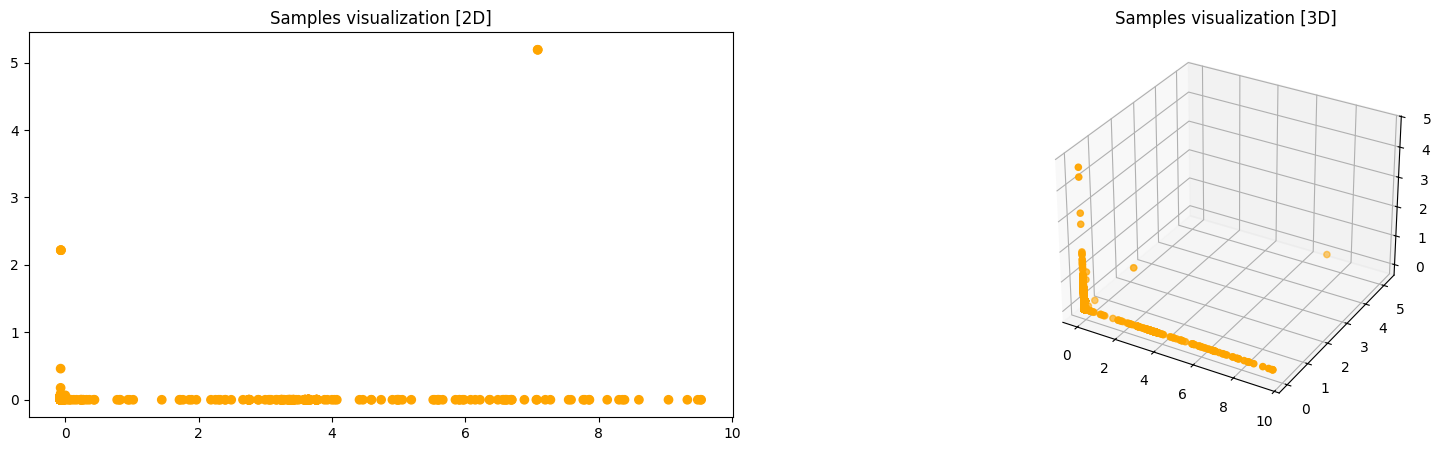

In [10]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_samples(samples, labels, title="Samples visualization", colors=["green", "orange"]):
    """ Visualize first three dimensions of samples. """
    # Convert colors to NumPy array
    colors = np.array(colors)
    # Create figure
    fig = plt.figure(figsize=(20, 5))

    # Plot first two dimensions on a 2D plot
    ax_2d = fig.add_subplot(1, 2, 1)
    ax_2d.set_title(f"{title} [2D]")
    ax_2d.scatter(samples[:, 0], samples[:, 1], c=colors[labels])

    # Plot first three dimensions on a 3D plot
    ax_3d = fig.add_subplot(1, 2, 2, projection="3d")
    ax_3d.set_title(f"{title} [3D]")
    ax_3d.scatter(samples[:, 0], samples[:, 1], samples[:, 2], c=colors[labels])

    print(fig)

# Visualize `StandardScaler` features (without dimensionality reduction)
visualize_samples(kdd_feat_std, y_std)

We will also use the following `timeit` function to monitor the training time of each algorithm:

In [11]:
import time
from contextlib import contextmanager

@contextmanager
def timeit(action="Timing"):
    # Record start time
    print(f"{action} started...")
    start_time = time.time()

    # Execute task
    yield

    # Compute and show elapsed time
    elapsed_time = time.time()-start_time
    print(f"{action} completed. Elapsed time: {elapsed_time:.2f}s")

# Test timing function by sleeping for 1 second
with timeit("Testing timing function"):
    time.sleep(1)

Testing timing function started...
Testing timing function completed. Elapsed time: 1.00s


### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a simple yet powerful technique used for dimensionality reduction. It is based on Singular Value Decomposition (SVD) of a matrix. Suppose matrix $\mathbf{M}$ of shape $m \times n$ represents $n$-dimensional features of $m$ samples, then according to SVD it can be decomposed into:

$$
\mathbf{M} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^*
$$

<div style="margin-top: 10px;">
    <img src="attachment:svd.png" width="25%" />
</div>

Where $\mathbf{U}$ is of shape $m \times m$ and its columns are called left singular vectors. Similarly, $\mathbf{V}^*$ is of shape $n \times n$ and its rows are called right singular vectors. $\mathbf{\Sigma}$ is a diagonal matrix of shape $m \times n$ and its diagonal elements are called singular values. For convenience reasons, here we call the $i$-th left and right singular vectors as well as corresponding singular value the $i$-th component.

To reduce the dimension of matrix $\mathbf{M}$, we first reorder $\mathbf{U}$, $\mathbf{\Sigma}$ and $\mathbf{V}^*$ by the singular value of each component, which can be seen as the "importance" of each component for the original data. Then, we truncate $\mathbf{U}$, $\mathbf{\Sigma}$ and $\mathbf{V}^*$ such that only the first $k (k < n)$ components are preserved. This gives as $\mathbf{U'}$ of shape $m \times k$, $\mathbf{\Sigma'}$ of shape $k \times k$ and $\mathbf{V'}^*$ of shape $k \times n$. Then, the result of PCA is given by:

$$
\mathbf{M'} = \mathbf{U'} \sqrt{\mathbf{\Sigma}}
$$

Below is the visualization of PCA result on two-dimensional data. The arrow shows the two components of PCA and the relative length of the arrow indicates the "importance" of each component:

<div style="margin-top: 10px;">
    <img src="attachment:pca-example.png" width="50%" />
</div>

Now, we will perform regular PCA on the `StandardScaler` features we have generated above. Note here we use `IncrementalPCA` rather than `PCA` for faster training, but the result should be roughly the same:

Figure(2000x500)


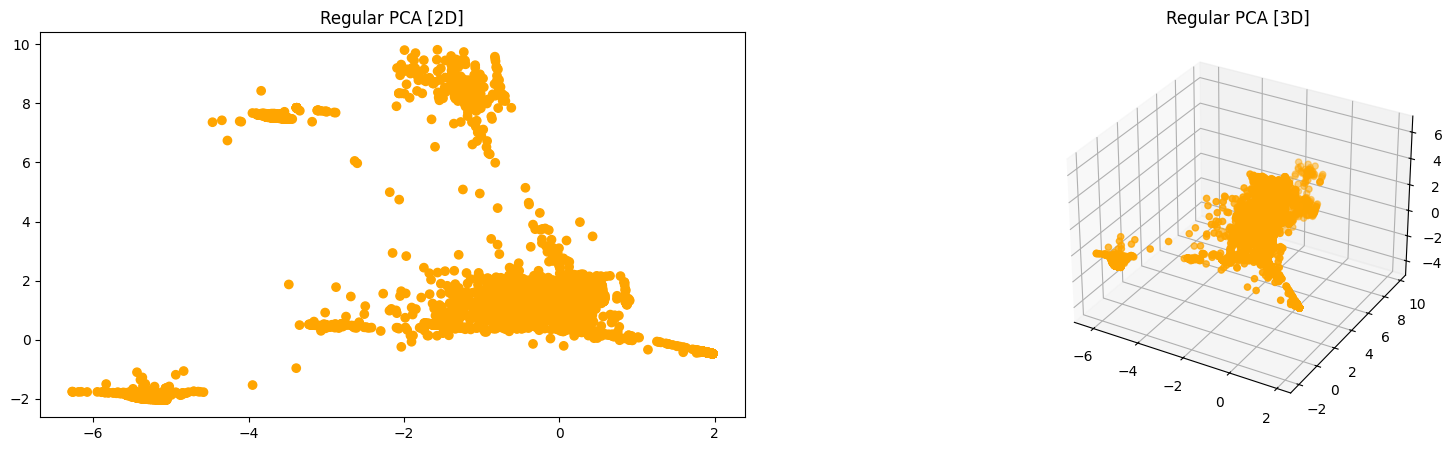

In [14]:
from sklearn.decomposition import IncrementalPCA

## [ TODO ]
# Perform regular PCA on `kdd_feat_std`
kdd_feat_pca = IncrementalPCA().fit_transform(kdd_feat_std)

# Plot regular PCA result
visualize_samples(kdd_feat_pca, y_std, title="Regular PCA")

### Kernel PCA

Before talking about kernel PCA, we need to introduce kernel method. Here is a simple introduction of kernel method:

> ... With kernel functions, we implictly map sample features (represented as points) into a higher-dimensional space, where the inner product of transformed sample features can be efficiently computed using the kernel function. Kernel method can be used in conjunction with linear regression algorithm or its varients to deal with non-linear mapping. It can also be used with SVM to make sample features linear serapable in an alternative space.

Like kernel SVM, in kernel PCA we implicitly map sample features into a higher-dimensional alternative space. This might sound contradictive to the purpose of dimensionality reduction, but what we want to achieve here is similar to the SVM case: to make transformed features linear separable. Then, we will perform PCA on transformed features to bring the number of dimensions down. Compared with regular PCA, this might separate features from different classes better and make visualization more intuitive.

<div>
    <img src="attachment:kernel-svm.png" width="50%" />
</div>

For kernel PCA (and all other kernel-based algorithms), the kernel functions are usually non-linear functions and must satisfy [Mercer's Theorm](https://en.wikipedia.org/wiki/Mercer%27s_theorem), which requires them to be symmetric positive-semidefinite functions. Here we introduce a few common kernel functions:

* Polynomial kernel: suppose we have two sample vector $\mathbf{x}$ and $\mathbf{y}$, then the polynomial kernel function $K(\mathbf{x}, \mathbf{y})$ is defined as:

$$
K(\mathbf{x}, \mathbf{y}) = (\mathbf{x}^T \mathbf{y} + c)^d
$$

Where $c \ge 0$ is a constant controlling the influence of each dimension and $d$ determines number of dimension of the transformed space.

* Radial basis function (RBF) kernel: the radial basis function kernel is defined as:

$$
K(\mathbf{x}, \mathbf{y}) = \exp(\frac{-||\mathbf{x} - \mathbf{y}||_2^2}{2 \sigma^2})
$$

Where $\sigma$ is a hyper-parameter. RBF kernel corresponds to an infinite-dimensional transformed space.

* Sigmoid kernel: the sigmoid kernel is defined as:

$$
K(\mathbf{x}, \mathbf{y}) = \tanh(\mathbf{x}^T \mathbf{y} + c)
$$

Where $c \ge 0$ is a constant controlling the influence of each dimension. Like RBF kernel, sigmoid kernel also corresponds to infinite-dimensional transformed space.

This time, let's try kernel PCA on the `MinMaxScaler` features instead. We will use different kernel functions and also try a few hyper-parameter settings for each kernel function type:

Kernel PCA (Polynomial; d = 3) started...
Kernel PCA (Polynomial; d = 3) completed. Elapsed time: 16.15s
Kernel PCA (Sigmoid; d = 6) started...
Kernel PCA (Sigmoid; d = 6) completed. Elapsed time: 12.89s
Figure(2000x500)
Figure(2000x500)


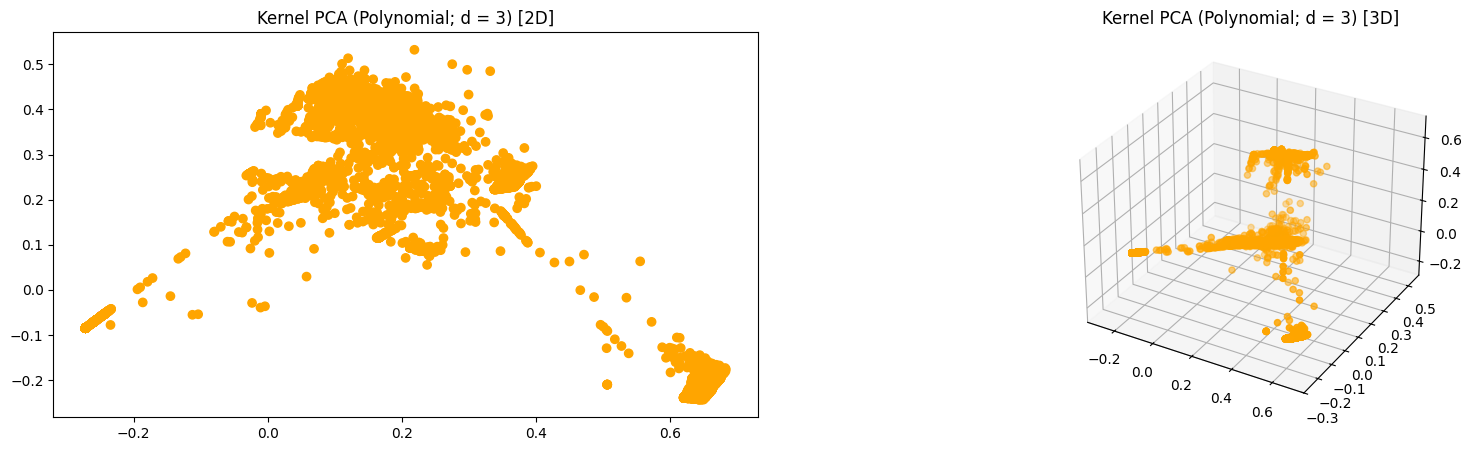

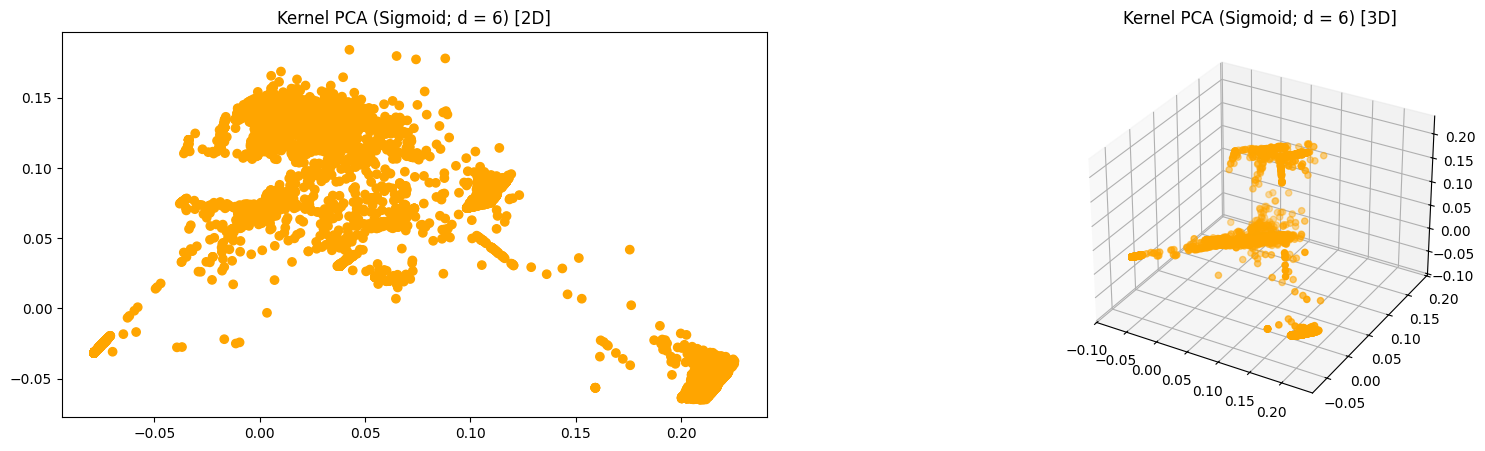

In [16]:
from sklearn.decomposition import KernelPCA

# Polynomial Kernel PCA (d = 3)
pca_poly_3 = KernelPCA(n_components=3, kernel="poly")
with timeit("Kernel PCA (Polynomial; d = 3)"):
    kdd_feat_pca_poly_3 = pca_poly_3.fit_transform(kdd_feat_minmax)

## [ TODO ]
# 1) Try a larger `d` for polynomial kernel (e.g. `d > 5`). Is your visualization result different?
# 2) Try other kernel functions, such as RBF or sigmoid kernel. Is your visualization result different?
pca_poly_6 = KernelPCA(n_components=6, kernel="sigmoid")
with timeit("Kernel PCA (Sigmoid; d = 6)"):
    kdd_feat_pca_poly_6 = pca_poly_6.fit_transform(kdd_feat_minmax)

# Plot kernel PCA result
visualize_samples(kdd_feat_pca_poly_3, y_minmax, title="Kernel PCA (Polynomial; d = 3)")
visualize_samples(kdd_feat_pca_poly_6, y_minmax, title="Kernel PCA (Sigmoid; d = 6)")

### t-distributed Stochastic Neighbor Embedding (t-SNE)

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction algorithm that works well on visualizing high-dimensional, non-linear features. It is widely applied in image processing, natural language processing (NLP), genomic data and speech recognition. Roughly speaking, t-SNE models the distribution of neighbors for each feature in the high-dimensional space as a Gaussian distribution. It then tries to find a t-distribution in the target, low-dimensional space that resembles the high-dimensional one as much as possible. Finally, t-SNE random places target features in the low-dimensional space, such that their pairwise distances conform to the t-distribution solved above. You can take a look at the references if you are interested in the details of the algorithm.

For t-SNE, we will run it on the `StandardScaler` features and see if it can visualize features better than PCA. We will also try different perplexity values, which control how many nearest neighbors are used to model the neighbor Gaussian distribution.

t-SNE (Perplexity = 80) started...
t-SNE (Perplexity = 80) completed. Elapsed time: 281.31s
t-SNE (Perplexity = 30) started...
t-SNE (Perplexity = 30) completed. Elapsed time: 412.68s
Figure(2000x500)
Figure(2000x500)


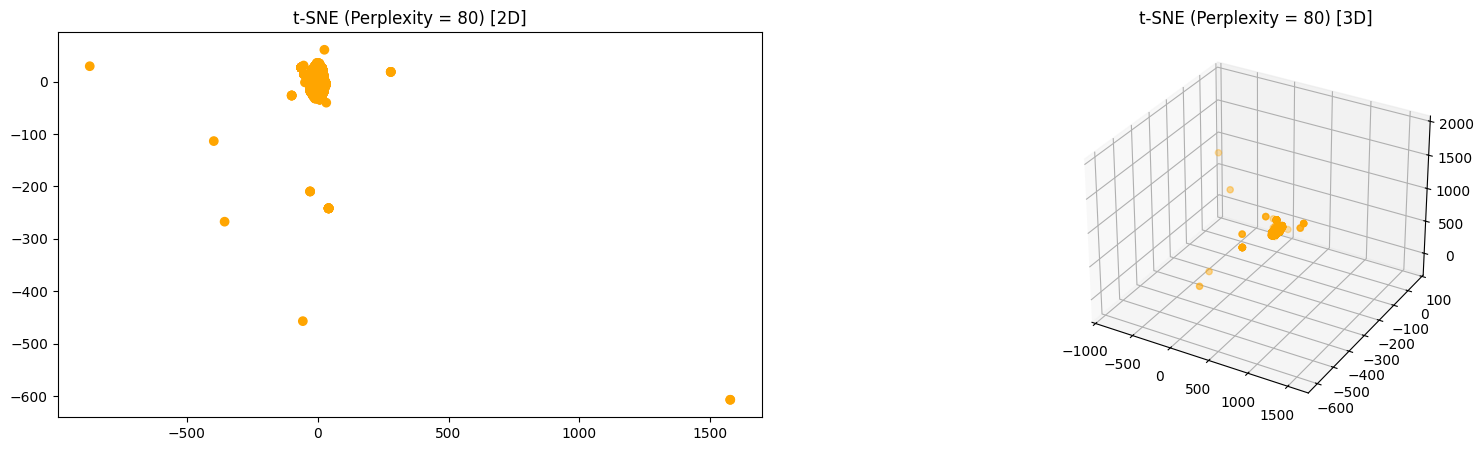

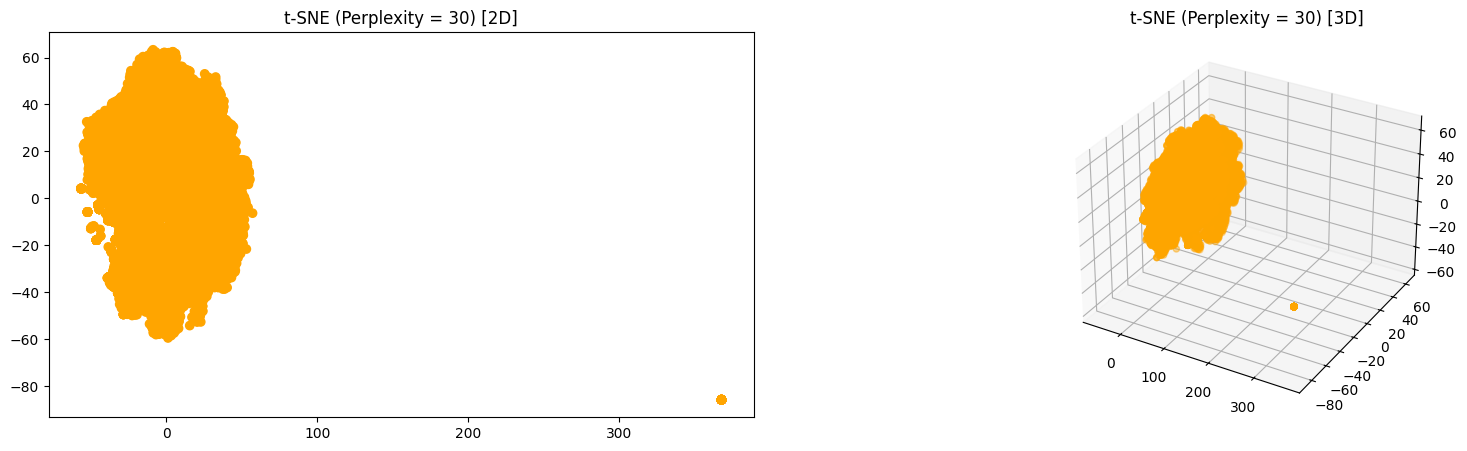

In [17]:
from sklearn.manifold import TSNE

# t-SNE (Perplexity set to 80)
t_sne_1 = TSNE(n_components=3, perplexity=80, init="pca", random_state=12345)
with timeit("t-SNE (Perplexity = 80)"):
    kdd_feat_t_sne_1 = t_sne_1.fit_transform(kdd_feat_std)

# t-SNE (Perplexity set to 40)
t_sne_2 = TSNE(n_components=3, init="pca", random_state=12345)
with timeit("t-SNE (Perplexity = 30)"):
    kdd_feat_t_sne_2 = t_sne_2.fit_transform(kdd_feat_std)

# Plot t-SNE result
visualize_samples(kdd_feat_t_sne_1, y_std, title="t-SNE (Perplexity = 80)")
visualize_samples(kdd_feat_t_sne_2, y_std, title="t-SNE (Perplexity = 30)")

## References

1. KDD Cup 1999 Dataset: https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html
2. Principal Component Analysis (PCA): https://en.wikipedia.org/wiki/Principal_component_analysis
3. Singular Value Decomposition (SVD): https://en.wikipedia.org/wiki/Singular_value_decomposition
4. Tutorial: Principal Components Analysis (PCA): https://lazyprogrammer.me/tutorial-principal-components-analysis-pca/
5. Kernel method: https://en.wikipedia.org/wiki/Kernel_method
6. Mercer's theorm: https://en.wikipedia.org/wiki/Mercer%27s_theorem
7. Kernel PCA: https://en.wikipedia.org/wiki/Kernel_principal_component_analysis
8. t-distributed Stochastic Neighbor Embedding (t-SNE): https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding
9. StatQuest: t-SNE, Clearly Explained: https://www.youtube.com/watch?v=NEaUSP4YerM
10. Introduction to t-SNE: https://www.datacamp.com/community/tutorials/introduction-t-sne